In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import plotly.graph_objects as go
import plotly.express as px
import math

In [10]:
df = pd.read_csv('IoTPond8.csv')
df.head()

,Unnamed: 0,Date,entry_id,Temperature (C),Turbidity(NTU),Dissolved Oxygen (mg/L),PH,Ammonia (mg/L),Nitrate (mg/L),Total_length (cm),Weight (g),Unnamed: 11
0,2021-06-18T13:06:49+01:00,18-06-2021,1,25.0000,95,14.697,8.34286,0.02520,0,6.821429,2.869286,`
1,2021-06-18T13:07:10+01:00,18-06-2021,2,24.8750,16,13.440,8.34286,0.00002,3114,6.821429,2.869286,NaN
2,2021-06-18T13:07:52+01:00,18-06-2021,3,24.6875,-2,13.600,8.36101,0.00042,2454,6.821429,2.869286,NaN
3,2021-06-18T13:08:12+01:00,18-06-2021,4,24.6875,-2,13.872,8.37463,0.01150,1745,6.821429,2.869286,NaN
4,2021-06-18T13:08:31+01:00,18-06-2021,5,24.6875,-1,14.209,8.36101,0.03008,1459,6.821429,2.869286,NaN


In [11]:
df.drop(["Unnamed: 11",'Date','entry_id'], axis = 1, inplace = True)

In [12]:
print(df.isnull().sum())

Unnamed: 0                 0
Temperature (C)            0
Turbidity(NTU)             0
Dissolved Oxygen (mg/L)    0
PH                         0
Ammonia (mg/L)             0
Nitrate (mg/L)             0
Total_length (cm)          0
Weight (g)                 0
dtype: int64


In [13]:
df = df.rename(columns={'Unnamed: 0': 'created_at'})

In [14]:
df['created_at'] = pd.to_datetime(df['created_at'], infer_datetime_format=True, utc=True)

In [15]:
df['created_at'] = pd.to_datetime(df.created_at)

#split columns
df["Date"] = df["created_at"].dt.day
df["month"] = df["created_at"].dt.month
df['year']=df['created_at'].dt.year
df['hour']=df['created_at'].dt.hour
df['minutes']=df['created_at'].dt.minute
df['seconds']=df['created_at'].dt.second

In [16]:
df.columns

Index(['created_at', 'Temperature (C)', 'Turbidity(NTU)',
       'Dissolved Oxygen (mg/L)', 'PH', 'Ammonia (mg/L)', 'Nitrate (mg/L)',
       'Total_length (cm)', 'Weight (g)', 'Date', 'month', 'year', 'hour',
       'minutes', 'seconds'],
      dtype='object')

In [17]:
 df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Date'] = pd.to_numeric(df['Date'])

In [18]:
 df['month'] = pd.to_datetime(df['month'], errors='coerce')

df['month'] = pd.to_numeric(df['month'])

In [19]:
 df['year'] = pd.to_datetime(df['year'], errors='coerce')

df['year'] = pd.to_numeric(df['year'])

In [20]:
df['hour'] = pd.to_datetime(df['hour'], errors='coerce')

df['hour'] = pd.to_numeric(df['hour'])

In [21]:
df['minutes'] = pd.to_datetime(df['minutes'], errors='coerce')

df['minutes'] = pd.to_numeric(df['minutes'])

In [22]:
df['seconds'] = pd.to_datetime(df['seconds'], errors='coerce')

df['seconds'] = pd.to_numeric(df['seconds'])

In [23]:
df.describe()

,Temperature (C),Turbidity(NTU),Dissolved Oxygen (mg/L),PH,Ammonia (mg/L),Nitrate (mg/L),Total_length (cm),Weight (g),Date,month,year,hour,minutes,seconds
count,70744.000000,70744.000000,70744.000000,70744.000000,70744.000000,70744.000000,70744.000000,70744.000000,70744.000000,70744.000000,70744.0,70744.000000,70744.000000,70744.00000
mean,24.922703,-0.782059,9.627173,3.555478,0.125155,667.153822,21.962352,144.045985,21.234621,7.724768,2021.0,11.789763,29.471913,29.46582
std,1.471358,41.589366,9.362911,4.999890,0.221859,448.354736,8.752105,123.328984,7.907892,1.097819,0.0,7.007554,17.267137,17.30448
min,-127.000000,-56.000000,0.000000,-3.137450,0.000020,0.000000,6.821429,2.869286,1.000000,6.000000,2021.0,0.000000,0.000000,0.00000
25%,24.437500,-51.000000,0.000000,-2.070680,0.001060,303.000000,16.874286,50.528571,18.000000,7.000000,2021.0,6.000000,15.000000,15.00000
50%,24.875000,22.000000,9.314000,7.475820,0.001110,363.000000,18.042857,61.114286,23.000000,8.000000,2021.0,12.000000,29.000000,29.00000
75%,25.375000,34.000000,15.670000,7.602920,0.003100,975.000000,32.085714,300.200000,27.000000,9.000000,2021.0,18.000000,44.000000,44.00000
max,30.500000,100.000000,42.261000,16.230770,0.996550,3338.000000,51.357143,841.200000,31.000000,12.000000,2021.0,23.000000,59.000000,59.00000


In [24]:
df.fillna(df.mean(), inplace=True)
df.replace([np.inf, -np.inf], 1e-9, inplace=True)

In [25]:
for i in range(1,len(df)):
    if df.loc[i, "PH"] < 6 or df.loc[i, "PH"] > 8.5:
        df.loc[i, "PH"] = df.loc[i-1,'PH']

In [27]:
for i in range(1,len(df)):
    if df.loc[i, "Dissolved Oxygen (mg/L)"] < 5 or df.loc[i, "Dissolved Oxygen (mg/L)"] > 20:
        df.loc[i, "Dissolved Oxygen (mg/L)"] = df.loc[i-1, "Dissolved Oxygen (mg/L)"]

In [29]:
for i in range(len(df)):
    if df.loc[i, "Temperature (C)"] < 20 or df.loc[i, "Temperature (C)"] > 30:
        df.loc[i, "Temperature (C)"] = df.loc[i-1, "Temperature (C)"]

In [30]:
df["Nitrate (mg/L)"] = df["Nitrate (mg/L)"].apply(np.sqrt)

In [31]:
df["Ammonia (mg/L)"] = np.log(df["Ammonia (mg/L)"]) / 10.0
df["Ammonia (mg/L)"] = df["Ammonia (mg/L)"].abs()


In [32]:
for i in range(1,len(df)):
    if df.loc[i, "Turbidity(NTU)"] < 0:
        df.loc[i, "Turbidity(NTU)"] = df.loc[i-1,'Turbidity(NTU)']

In [33]:
df.describe()

,Temperature (C),Turbidity(NTU),Dissolved Oxygen (mg/L),PH,Ammonia (mg/L),Nitrate (mg/L),Total_length (cm),Weight (g),Date,month,year,hour,minutes,seconds
count,70744.000000,70744.000000,70744.000000,70744.000000,70744.000000,70744.000000,70744.000000,70744.000000,70744.000000,70744.000000,70744.0,70744.000000,70744.000000,70744.00000
mean,24.933566,31.721277,12.470072,7.013538,0.529451,24.469280,21.962352,144.045985,21.234621,7.724768,2021.0,11.789763,29.471913,29.46582
std,0.723395,17.371050,4.418285,0.924290,0.263372,8.270981,8.752105,123.328984,7.907892,1.097819,0.0,7.007554,17.267137,17.30448
min,23.125000,0.000000,5.003000,6.000490,0.000346,0.000000,6.821429,2.869286,1.000000,6.000000,2021.0,0.000000,0.000000,0.00000
25%,24.437500,16.000000,8.458000,6.000490,0.577635,17.406895,16.874286,50.528571,18.000000,7.000000,2021.0,6.000000,15.000000,15.00000
50%,24.875000,32.000000,12.356000,7.475820,0.680340,19.052559,18.042857,61.114286,23.000000,8.000000,2021.0,12.000000,29.000000,29.00000
75%,25.375000,38.000000,16.194000,7.602920,0.684949,31.224990,32.085714,300.200000,27.000000,9.000000,2021.0,18.000000,44.000000,44.00000
max,28.625000,100.000000,19.998000,8.497200,1.081978,57.775427,51.357143,841.200000,31.000000,12.000000,2021.0,23.000000,59.000000,59.00000


In [34]:
columns=df.columns.tolist()
columns=columns[-6:]+columns[0:-6]
df=df[columns]

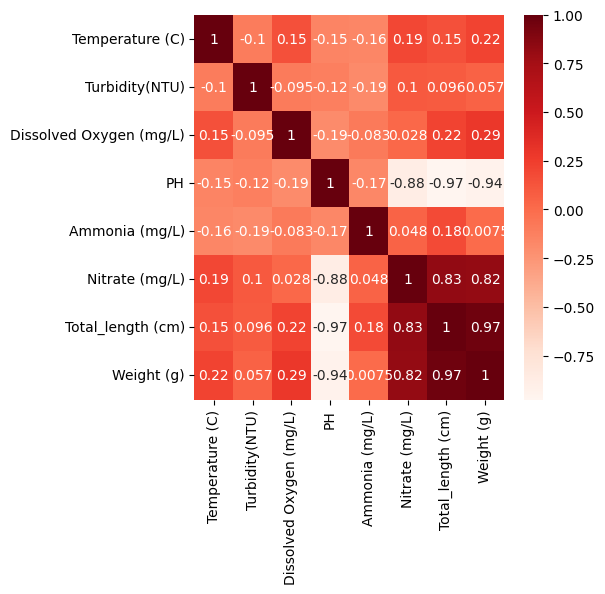

In [35]:
#creating a heatmap to show the correlation between the features
plt.figure(figsize=(5, 5))
x=df.iloc[:,6:]
cor = x.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

In [38]:
df.drop('created_at',axis=1,inplace=True)

In [39]:
df.to_csv('pp8.csv', index=False)